In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../..', 'src'))
sys.path.insert(0, src_dir)

from model import WRCircuit
from plots import animate_spiking_activity

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

CUDA backend failed to initialize: INTERNAL: no supported devices found for platform CUDA.(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


cpu


In [3]:
num_exc_neurons = (50, 50)
num_inh_neurons = np.prod(num_exc_neurons)//4
FNSnet = WRCircuit(num_exc_neurons, num_inh_neurons)

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


KeyboardInterrupt: 

In [4]:
if np.product(FNSnet.E.size) <= 50:
    conn = FNSnet.E2E.proj.comm.conn
    positions = FNSnet.E.positions
    if len(positions[0]) == 1:
        positions = [(x[0], 0) for x in positions]
    G = nx.from_numpy_array(conn.require("conn_mat"), create_using=nx.DiGraph())
    nx.draw(
        G,
        pos=positions,
        connectionstyle="arc3,rad=0.5",
        node_color="b",
        edge_color="b",
        node_size=20,
        width=0.5,
    )

    conn = FNSnet.I2I.proj.comm.conn
    positions = FNSnet.I.positions
    if len(positions[0]) == 1:
        positions = [(x[0], 0) for x in positions]
    G = nx.from_numpy_array(conn.require("conn_mat"), create_using=nx.DiGraph())
    nx.draw_networkx_nodes(G, pos=positions, node_color="r", node_size=20)

    plt.show()


In [5]:
# input, T = bp.inputs.section_input([0.0, 400.0], [100.0, 100.0], return_length=True)
# inputs = np.zeros(FNSnet.E.size + (len(input),))
# inputs[0, 0] = input
# inputs = inputs.reshape(-1, inputs.shape[-1])

# inputs = np.zeros(FNSnet.E.size).flatten() + 400.0
# inputs = np.tile(
#     inputs, (int(T / bp.share.load("dt")), 1)
# ).transpose()  # A matrix doesn't work. Maybe add a new input variable post-hoc that
# targets a specific set of indices?

# input = 400.0
# input_idxs = (range(2), range(2))
# FNSnet.stimulus = bp.dyn.InputVar([len(x) for x in input_idxs])
# FNSnet.E.add_inp_fun("", self.Ein)

def stimulus():
    out = jnp.zeros(FNSnet.E.size)
    t = bp.share['t']
    # out = out.at[0:4, 0:4].add(jnp.where(jnp.logical_and(t > 0., t < 700.), 330.0, 0.0))
    # out = out.at[0:4, 0:4].add(jnp.where(jnp.logical_and(t > 400., t < 407.), 400.0, 0.0))
    return out.flatten()

In [6]:
T = 1000.0
FNSnet.stimulus = bp.dyn.PoissonInput(FNSnet.Ein.input, np.prod(FNSnet.E.size), 100.0, 1.0)
runner = bp.DSRunner(
    FNSnet,
    monitors=["E.spike", "I.spike", "E.V", "I.V"],
    inputs=[
        # ("Ein.input", stimulus, 'func'),
         ("Ein.input", 320),
    ],
    jit = True
)
runner.run(T)
t = runner.mon["ts"].view()  # [1000:]
X = runner.mon["E.spike"].view()  # [1000:]
Ve = runner.mon["E.V"].view()  # [1000:]
Vi = runner.mon["I.V"].view()  # [1000:]

Predict 10000 steps: : 100%|██████████| 10000/10000 [00:05<00:00, 1773.66it/s]


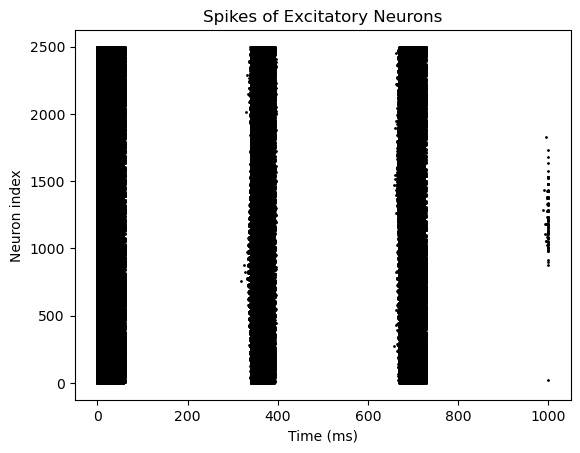

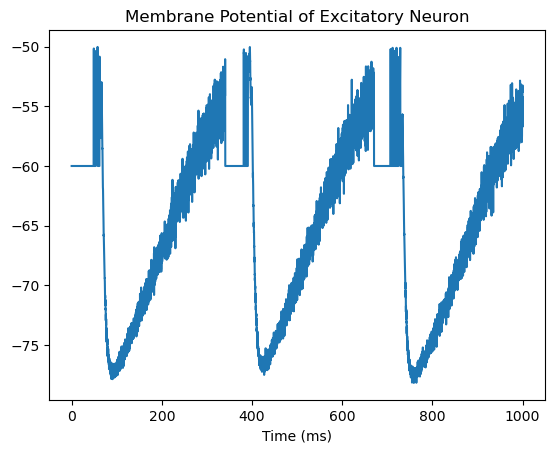

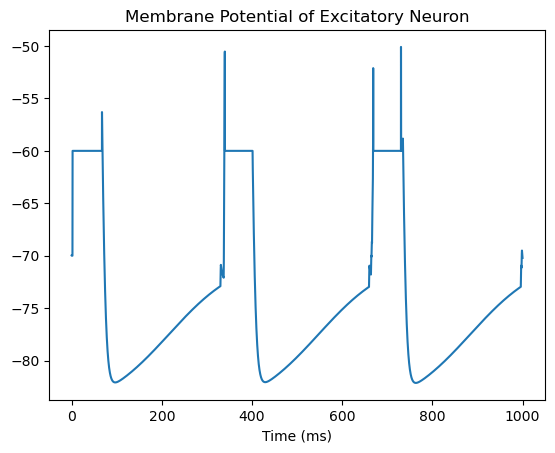

In [7]:
bp.visualize.raster_plot(t, X, title="Spikes of Excitatory Neurons", show=True)
bp.visualize.line_plot(t, Ve[:, 2], title="Membrane Potential of Excitatory Neuron", show=True)
bp.visualize.line_plot(t, Vi[:, 2], title="Membrane Potential of Excitatory Neuron", show=True)

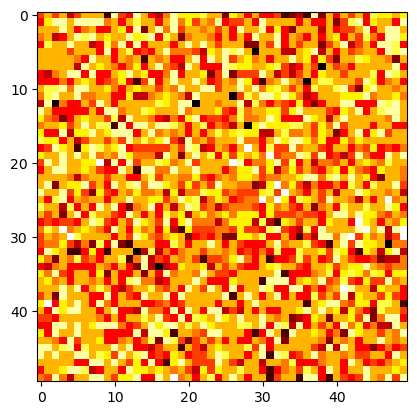

[[40 42 40 ... 43 42 43]
 [39 43 45 ... 42 39 45]
 [42 42 42 ... 45 45 42]
 ...
 [42 42 42 ... 41 42 43]
 [39 42 42 ... 42 43 42]
 [41 40 45 ... 45 40 45]]


In [8]:
R = X.sum(axis=0)
R = R.reshape(FNSnet.E.size)
plt.imshow(R, cmap="hot", interpolation="nearest")
plt.show()
print(R)

In [9]:
%matplotlib inline
from IPython.display import HTML
ani = animate_spiking_activity(FNSnet, runner, ms_per_s=100, fps=12, window_size_ms=10)
# ani.save("spiking_activity.mp4", writer="ffmpeg", fps=30)
HTML(ani.to_jshtml())

AttributeError: 'WRCircuit' object has no attribute 'domain'